# 02 — Dynamic Time Warping

**Dataset:** `drive_day_2026`

**Question:** Do time-warped windows recur at signal-derived candidate periods?

## Method

Compare period-separated windows against non-period controls using one-second Sakoe-Chiba bands resolved at native sample rate.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "lap_estimation").exists():
    ROOT = ROOT.parent
if not (ROOT / "lap_estimation").exists():
    raise FileNotFoundError("Repository root not found")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lap_estimation.plotting_classical import render_dtw_diagnostics
from lap_estimation.artifacts import load_experiment_metrics
from lap_estimation.config import RANDOM_SEED
from lap_estimation.data import prepare_recording_manifest
from lap_estimation.datasets import resolve_dataset
from lap_estimation.runners import run_experiment

DATASET_KEY = "drive_day_2026"
dataset = resolve_dataset(DATASET_KEY, ROOT)
ARTIFACT_ROOT = dataset.artifact_root
np.random.seed(RANDOM_SEED)
sns.set_theme(style="ticks", palette="colorblind", context="notebook")
manifest = prepare_recording_manifest(dataset)
manifest[["recording_id", "duration_s", "motion_status", "control_candidate", "clock_provenance", "split"]]

,recording_id,duration_s,motion_status,control_candidate,clock_provenance,split
0,07173121b1534f1eadb8b127005d4eff70872388074c2b...,21.9,moving_candidate,False,recorded_time_column,train
1,1a8433bf1168531d6f7c2deb5c37b27de5ddf1d9f65316...,21.9,moving_candidate,False,recorded_time_column,train
2,1cca7c275163fc193899535ebb0c13f26676e8568d3c8a...,37.9,moving_candidate,False,recorded_time_column,train
3,200a690cbeb5a4d9f415d6a933e60aa13a0cf5ee5c03c7...,57.8,moving_candidate,False,recorded_time_column,train
4,25aa01e1dcbaea32c062e01b0f782c938c34163fc58af1...,73.7,moving_candidate,False,recorded_time_column,train
5,2f775054c4e7bb342cf49e0ee66406e82353c274c103fc...,25.9,moving_candidate,False,recorded_time_column,train
6,382db1f8ede73f956341d7b461790125339762ec9d7cc9...,57.8,stationary_candidate,True,recorded_time_column,train
7,4c8d0190b666e26315ce16c862ca2e968d576e14537487...,21.9,moving_candidate,False,recorded_time_column,train
8,554af5ad576c1c1d069356649e3bd1e2699a5801f6a0fa...,17.9,stationary_candidate,True,recorded_time_column,train
9,564a12f3d813c10242613a907d2b4981e7296739ba9a56...,57.8,stationary_candidate,True,recorded_time_column,train


In [2]:
EXPERIMENT_OPTIONS = {}
EXPERIMENT_OPTIONS

{}

,task,split,metric,value,sample_count,reference_source
0,period_pair_retrieval,train,median_matched_dtw,0.769872,63,signal_period_teacher
1,period_pair_retrieval,train,matched_better_than_control_rate,0.571429,63,within_recording_control
2,period_pair_retrieval,validation,median_matched_dtw,0.448940,30,signal_period_teacher
3,period_pair_retrieval,validation,matched_better_than_control_rate,0.666667,30,within_recording_control
4,period_pair_retrieval,test,median_matched_dtw,2.273467,16,signal_period_teacher
5,period_pair_retrieval,test,matched_better_than_control_rate,0.500000,16,within_recording_control
6,period_pair_retrieval,all,median_matched_dtw,0.920414,109,signal_period_teacher
7,period_pair_retrieval,all,matched_better_than_control_rate,0.587156,109,within_recording_control


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recording_id,109,13,200a690cbeb5a4d9f415d6a933e60aa13a0cf5ee5c03c7...,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment_id,109,10,pair_0,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_s,109.0,NaN,NaN,NaN,8.495413,5.831942,0.0,4.0,8.0,14.0,18.0
end_s,109.0,NaN,NaN,NaN,18.495413,5.831942,10.0,14.0,18.0,24.0,28.0
prediction_kind,109,1,dtw_period_match,109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score,109.0,NaN,NaN,NaN,0.190118,1.052992,-2.236863,-0.141258,0.001472,0.645616,3.490625
label_status,109,1,provisional_unverified,109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
predicted_period_s,109.0,NaN,NaN,NaN,35.343119,23.829018,16.6,22.5,28.3,42.3,105.0
matched_distance,109.0,NaN,NaN,NaN,1.22793,1.08676,0.033605,0.039275,0.920414,2.187151,3.86428
control_distance,109.0,NaN,NaN,NaN,1.418048,1.182152,0.033847,0.040742,1.46199,2.41116,3.754892


,count,mean,median,std,min,max
recording_id,,,,,,
6faa006353747cbeb4e6d2e90954728110cb94fabfcd41e319270d4cde22f117,10,1.802689,1.832471,1.219609,-0.170541,3.490625
5e9e04831922d971561f6ffb53b2c77744d905cca01dcc2fe043d10b2f63c613,3,0.714973,0.611752,0.273542,0.508060,1.025107
e57d3de89d6f2a3165aa05beee7b611f60923e090254337c1b48f744c78db52d,10,0.548817,0.462007,1.185846,-1.244628,1.937406
629d7d57091b71c5c0c2c6f42218702e454b4ae60e20636885741c7c22fe1bb4,10,0.297638,0.359496,0.505482,-0.435263,0.892961
6939b3836a088e9113eb3bffcf362bed963a71bbd9012ecb56dc61e6d500da39,10,0.258490,0.228030,0.582540,-0.729675,1.274598
667a6e15a4394db30d7cce7a4db319041453bfa306b566a87e84b213d81efb29,10,0.521387,0.216594,1.315162,-1.362457,2.944650
c5c639ca1fa3038e565a432a960cb53f6ce533ad9612d27f229f6527fcf0edac,1,0.004335,0.004335,NaN,0.004335,0.004335
564a12f3d813c10242613a907d2b4981e7296739ba9a560571b3547dab1daa7f,10,0.003216,0.001956,0.004994,-0.003580,0.013573
382db1f8ede73f956341d7b461790125339762ec9d7cc96480f20aefe04d77e1,10,0.000434,0.000444,0.001831,-0.002517,0.004464


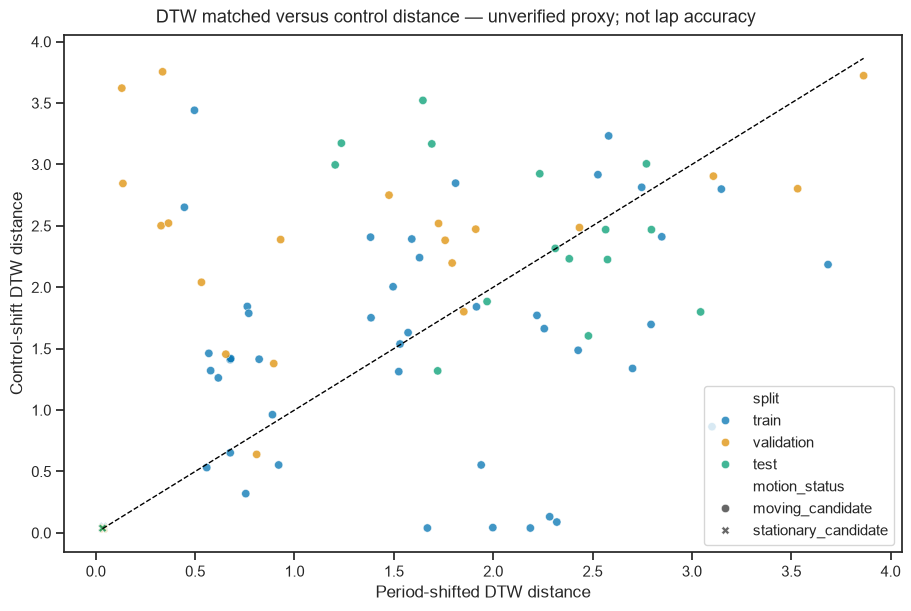

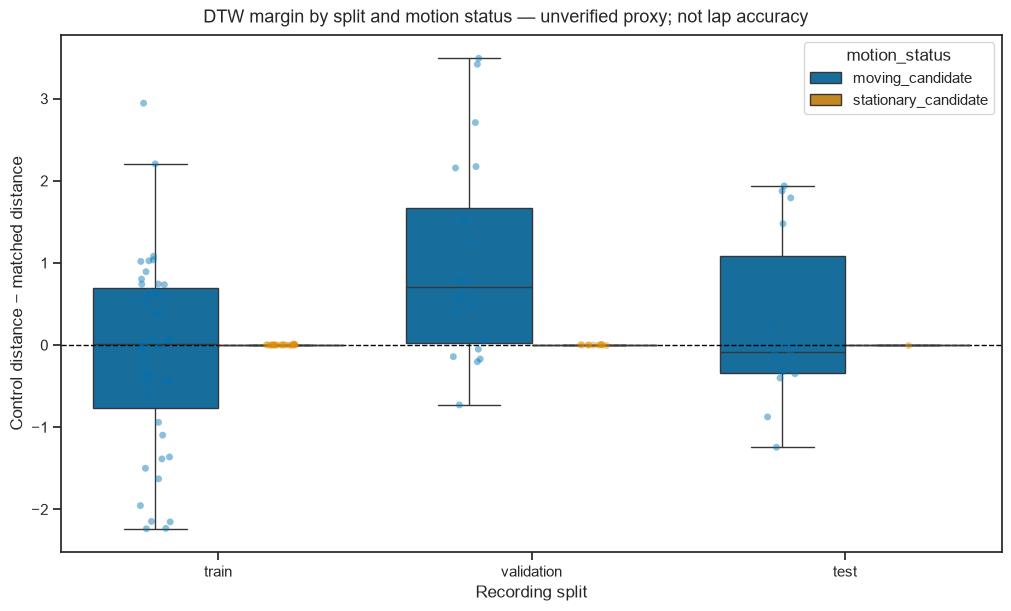

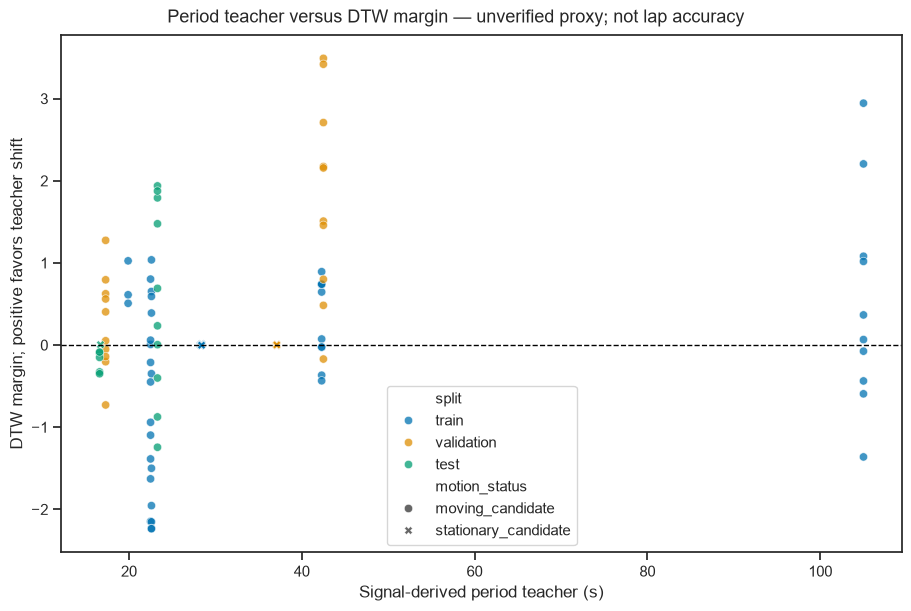

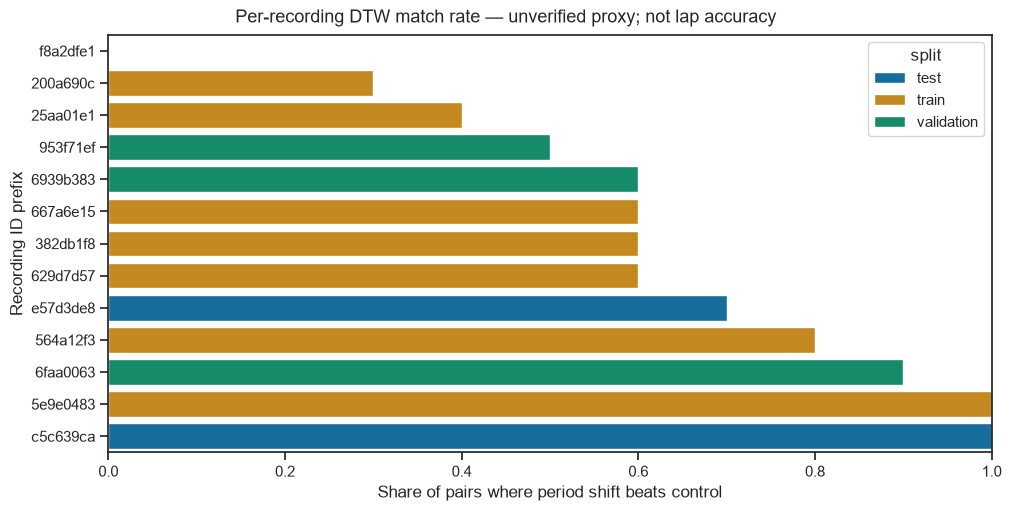

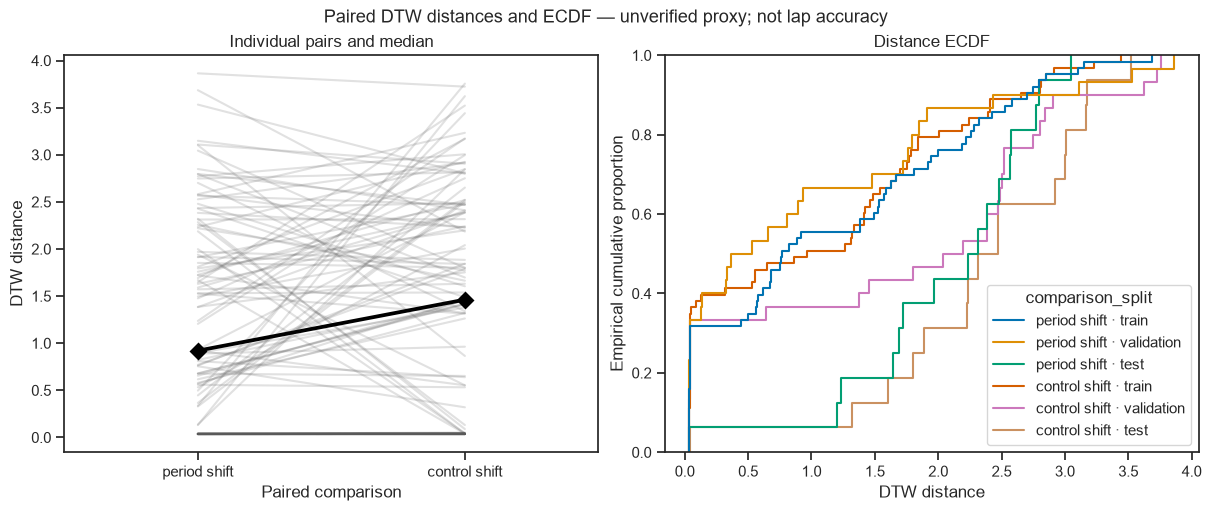

In [3]:
METHOD = "02_dtw"
result = run_experiment(METHOD, ROOT, dataset_key=DATASET_KEY, **EXPERIMENT_OPTIONS)
run_manifest = json.loads((result.output_dir / "manifest.json").read_text(encoding="utf-8"))
display(result.metrics)
display(result.predictions.describe(include="all").T)
display(result.predictions.groupby("recording_id")["score"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("median", ascending=False))
diagnostic_figures = render_dtw_diagnostics(result.predictions, run_manifest, result.output_dir)
for figure in diagnostic_figures.values():
    display(figure)
    plt.close(figure)

In [4]:
pd.Series(
    {
        "status": run_manifest["status"],
        "runtime_s": run_manifest["runtime_s"],
        "clock_provenance": run_manifest["data_provenance"]["clock_provenance"],
        "sample_rate_hz": run_manifest["data_provenance"]["native_sample_rate_hz"],
        "channels": run_manifest["data_provenance"]["selected_channels"],
        "label_provenance": run_manifest["label_provenance"],
    },
    name="value",
).to_frame()

,value
status,complete
runtime_s,2.383
clock_provenance,recorded_time_column
sample_rate_hz,10.0
channels,"[Motor RPM [Rpm], MC Duty Cycle [%], AC Curren..."
label_provenance,signal_period_teacher_unverified


## Reading

Positive held-out control margin supports teacher-period matching only. It does not validate laps.

No lap precision, recall, count error, or duration error can be reported without independently reviewed boundaries.